# Closed-Form NCA — Texture Synthesis

**MLP Lift → Diagonal Linear Dynamics → MLP Project**


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device('cuda')
print(f'Using device: {device}')

Using device: cuda


## Model

## VGG Style Loss

Gram-matrix loss at 5 VGG-19 layers (conv1_1 through conv5_1).

In [6]:
class StyleLoss(nn.Module):
    """VGG-19 Gram-matrix style loss."""

    STYLE_LAYERS = [1, 6, 11, 20, 29]  # relu1_1, relu2_1, relu3_1, relu4_1, relu5_1

    def __init__(self, target_img, device='cuda'):
        """target_img: [3, H, W] tensor in [0, 1]."""
        super().__init__()
        self.device = device

        # ImageNet normalization — create directly on device
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1))

        # Frozen VGG-19 features
        vgg = torchvision.models.vgg19(weights='DEFAULT').features.to(device).eval()
        for p in vgg.parameters():
            p.requires_grad_(False)
        self.vgg = vgg

        # Precompute target Gram matrices
        with torch.no_grad():
            self.target_grams = self._extract_grams(target_img.unsqueeze(0).to(device))

    def _normalize(self, x):
        return (x - self.mean) / self.std

    def _extract_grams(self, x):
        """Extract Gram matrices at style layers. x: [B, 3, H, W] in [0,1]."""
        x = self._normalize(x)
        grams = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.STYLE_LAYERS:
                b, c, h, w = x.shape
                F_map = x.reshape(b, c, -1)
                G = (F_map @ F_map.transpose(1, 2)) / (c * h * w)
                grams.append(G)
        return grams

    def forward(self, x):
        """x: [B, 3, H, W] in [0, 1]. Returns scalar loss."""
        input_grams = self._extract_grams(x)
        loss = sum(
            (ig - tg).pow(2).mean()
            for ig, tg in zip(input_grams, self.target_grams)
        )
        return loss


print('StyleLoss ready')

StyleLoss ready


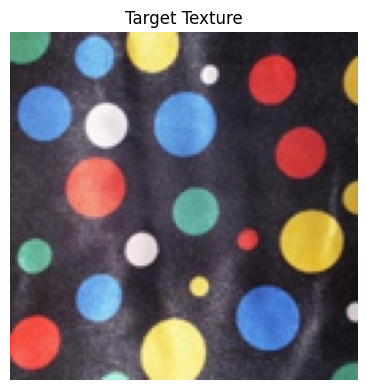

Shape: torch.Size([3, 128, 128])


In [7]:
import requests
import io
import PIL

def imread(url, max_size=None, mode=None):
  if url.startswith(('http:', 'https:')):
    # wikimedia requires a user agent
    headers = {
      "User-Agent": "Requests in Colab/0.0 (https://colab.research.google.com/; no-reply@google.com) requests/0.0"
    }
    r = requests.get(url, headers=headers)
    f = io.BytesIO(r.content)
  else:
    f = url
  img = PIL.Image.open(f)
  if max_size is not None:
    img.thumbnail((max_size, max_size))
  if mode is not None:
    img = img.convert(mode)
  img = np.float32(img)/255.0
  return img

url = 'https://www.robots.ox.ac.uk/~vgg/data/dtd/thumbs/dotted/dotted_0201.jpg'
target_texture = imread(url, max_size=128)
target_texture = torch.tensor(target_texture).permute(2, 1, 0).to(device)

plt.figure(figsize=(4, 4))
plt.imshow(target_texture.cpu().permute(1, 2, 0))
plt.title('Target Texture')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Shape: {target_texture.shape}')

In [8]:

import torchvision.models as models

def imread(url, max_size=None, mode=None):
  if url.startswith(('http:', 'https:')):
    # wikimedia requires a user agent
    headers = {
      "User-Agent": "Requests in Colab/0.0 (https://colab.research.google.com/; no-reply@google.com) requests/0.0"
    }
    r = requests.get(url, headers=headers)
    f = io.BytesIO(r.content)
  else:
    f = url
  img = PIL.Image.open(f)
  if max_size is not None:
    img.thumbnail((max_size, max_size))
  if mode is not None:
    img = img.convert(mode)
  img = np.float32(img)/255.0
  return img

#@title VGG16 Sliced OT Style Model
vgg16 = models.vgg16(weights='IMAGENET1K_V1').features

def calc_styles_vgg(imgs):
  style_layers = [1, 6, 11, 18, 25]
  mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
  std = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
  x = (imgs-mean) / std
  b, c, h, w = x.shape
  features = [x.reshape(b, c, h*w)]
  for i, layer in enumerate(vgg16[:max(style_layers)+1]):
    x = layer(x)
    if i in style_layers:
      b, c, h, w = x.shape
      features.append(x.reshape(b, c, h*w))
  return features

def project_sort(x, proj):
  return torch.einsum('bcn,cp->bpn', x, proj).sort()[0]

def ot_loss(source, target, proj_n=32):
  ch, n = source.shape[-2:]
  projs = F.normalize(torch.randn(ch, proj_n), dim=0)
  source_proj = project_sort(source, projs)
  target_proj = project_sort(target, projs)
  target_interp = F.interpolate(target_proj, n, mode='nearest')
  return (source_proj-target_interp).square().sum()

def create_vgg_loss(target_img):
  yy = calc_styles_vgg(target_img)
  def loss_f(imgs):
    xx = calc_styles_vgg(imgs)
    return sum(ot_loss(x, y) for x, y in zip(xx, yy))
  return loss_f

def to_nchw(img):
  img = torch.as_tensor(img)
  if len(img.shape) == 3:
    img = img[None,...]
  return img.permute(0, 3, 1, 2)


with torch.no_grad():
  loss_f = create_vgg_loss(target_texture.unsqueeze(0))


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ClosedFormNCA(nn.Module):
    """
    Fast Closed-form NCA with Dense Channel Mixing and Marginal Stability.
    Mathematically forces the max eigenvalue to 0, allowing complex Turing
    patterns to form perfectly without ever exploding at t=10000.
    """

    def __init__(self, in_ch=3, latent_ch=48, default_grid_size=64, hidden=64, update_rate=0.5):
        super().__init__()
        self.in_ch = in_ch
        self.C = latent_ch
        self.default_grid = default_grid_size
        self.update_rate = update_rate

        self.lift = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, padding_mode='circular'), nn.GELU(),
            nn.Conv2d(hidden, latent_ch, 3, padding=1, padding_mode='circular'),
        )

        self.project = nn.Sequential(
            nn.Conv2d(latent_ch, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 1), nn.GELU(),
            nn.Conv2d(hidden, in_ch, 1), nn.Sigmoid(),
        )

        # 1. Channel Mixing (Orthogonal matrix U)
        self.U_raw = nn.Parameter(torch.randn(latent_ch, latent_ch) * 0.1)

        # 2. Spatial Dynamics: Fully unconstrained 3x3 depthwise kernel
        self.spatial_kernel = nn.Parameter(torch.randn(latent_ch, 1, 3, 3) * 0.1)

    @property
    def device(self):
        return self.U_raw.device

    def _get_U(self):
        # Skew-symmetric matrix exponential yields an exact Orthogonal matrix
        skew = self.U_raw - self.U_raw.T
        return torch.matrix_exp(skew)

    def _get_stable_dynamics(self, H, W):
        """
        Extracts frequency and spatial multipliers, strictly shifting them so
        the maximum growth rate is 0.0. This prevents exponential explosion.
        """
        k_pad = F.pad(self.spatial_kernel, (0, W - 3, 0, H - 3))
        k_pad = torch.roll(k_pad, shifts=(-1, -1), dims=(2, 3))

        # [C, 1, H, W] -> [C, H, W]
        g_hat = torch.fft.fft2(k_pad).squeeze(1)

        # Find the maximum growth rate per channel
        max_real = g_hat.real.amax(dim=(1, 2), keepdim=True) # Shape: [C, 1, 1]

        # 1. Shift the frequency spectrum down (Max real eigenvalue is now exactly 0)
        g_hat_stable = (g_hat.real - max_real) + 1j * g_hat.imag

        # 2. Shift the spatial kernel to perfectly match
        # (Subtracting from the DC center pixel identical to shifting the whole FFT)
        k_stable = self.spatial_kernel.clone()
        k_stable[:, 0, 1, 1] = k_stable[:, 0, 1, 1] - max_real.squeeze()

        return g_hat_stable, k_stable

    def _sample_noise(self, batch_size=1, H=None, W=None):
        H = H or self.default_grid
        W = W or self.default_grid
        return torch.randn(batch_size, self.in_ch, H, W, device=self.device)

    def forward(self, t, x0=None, batch_size=1):
        if x0 is None:
            x0 = self._sample_noise(batch_size)
        elif x0.dim() == 3:
            x0 = x0.unsqueeze(0)

        H, W = x0.shape[2:]
        x0_latent = self.lift(x0)
        X0 = torch.fft.fft2(x0_latent)

        U = self._get_U()
        g_hat_stable, _ = self._get_stable_dynamics(H, W)

        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t, device=self.device)
        t = t.view(-1, 1, 1, 1).to(self.device)

        # Mix channels into Diagonal basis
        X_z = torch.einsum('cd, bdhw -> bchw', U.T.to(X0.dtype), X0)

        # Apply stable spatial update
        phase = t * self.update_rate * g_hat_stable.unsqueeze(0)
        X_zt = X_z * torch.exp(phase)

        # Unmix channels
        Xt = torch.einsum('cd, bdhw -> bchw', U.to(X_zt.dtype), X_zt)

        return self.project(torch.fft.ifft2(Xt).real)

    # ---- Recurrent ----

    def _get_stable_kernel_local(self):
      """
      Stabilize the 3×3 kernel using only its own entries.
      Evaluate frequency response on a small fixed grid —
      independent of the actual simulation resolution.
      """
      k = self.spatial_kernel  # [C, 1, 3, 3]

      # Fixed small grid — captures full spectral content of a 3×3 kernel
      REF = 8
      k_pad = F.pad(k, (0, REF - 3, 0, REF - 3))
      k_pad = torch.roll(k_pad, shifts=(-1, -1), dims=(2, 3))
      g_hat = torch.fft.fft2(k_pad).squeeze(1)  # [C, REF, REF]

      max_real = g_hat.real.amax(dim=(1, 2))  # [C]

      k_stable = k.clone()
      k_stable[:, 0, 1, 1] = k_stable[:, 0, 1, 1] - max_real
      return k_stable

    def step_latent(self, state_latent, dt=0.5):
        if state_latent.dim() == 3:
            state_latent = state_latent.unsqueeze(0)

        def dynamics(x):
            U = self._get_U()
            _, k_stable = self._get_stable_dynamics(x.shape[2], x.shape[3])
            z = F.conv2d(x, U.T.unsqueeze(-1).unsqueeze(-1))
            z_pad = F.pad(z, (1, 1, 1, 1), mode='circular')
            delta_z = F.conv2d(z_pad, k_stable, groups=self.C)
            return F.conv2d(delta_z, U.unsqueeze(-1).unsqueeze(-1))

        h = dt
        k1 = dynamics(state_latent)
        k2 = dynamics(state_latent + 0.5 * h * k1)
        k3 = dynamics(state_latent + 0.5 * h * k2)
        k4 = dynamics(state_latent + h * k3)

        mask = (torch.rand(
            state_latent.shape[0], 1,
            state_latent.shape[2], state_latent.shape[3],
            device=state_latent.device
        ) < self.update_rate).float()

        delta = (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        delta = delta * mask

        return state_latent + delta

    def get_initial_latent(self, x0=None, batch_size=1):
        if x0 is None:
            x0 = self._sample_noise(batch_size)
        elif x0.dim() == 3:
            x0 = x0.unsqueeze(0)
        return self.lift(x0).detach().clone()

## Training

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm
import requests
import io
import PIL


def train_nca():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    batch_size = 4
    iterations = 3000
    lr = 1e-3
    t_min, t_max = 30.0, 60.0 * 5
    GRID = 64
    H, W = GRID, GRID
    LAT = 12 * 2
    HID = 24 * 2
    UPD = .5
    model = ClosedFormNCA(in_ch=3, latent_ch=LAT, hidden=HID, default_grid_size=GRID, update_rate=UPD).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)


    print(f"Starting training on {device}...")
    pbar = tqdm(range(iterations))

    for step in pbar:
        optimizer.zero_grad()

        # 1. Sample dynamic initial noise matching the target image resolution
        # We explicitly pass x0 to control the grid size rather than relying on default_grid
        x0 = torch.randn(batch_size, 3, H, W, device=device)

        # 2. Sample random continuous times `t` for the batch
        # We want the model to learn valid textures anywhere between t_min and t_max
        t = torch.empty(batch_size, device=device).uniform_(t_min, t_max)

        # 3. Closed-Form Forward Pass (O(1) time complexity)
        # Because we use the frequency domain matrix exponential, this computes
        # the exact state at time 't' without needing a recurrent for-loop.
        pred_texture = model(t, x0=x0)

        # 4. Compute Style Loss (Target is broadcasted to match batch size)
        # loss = style_loss_fn(pred_texture, target_texture.expand(batch_size, -1, -1, -1))
        loss = loss_f(pred_texture)

        # 5. Backprop & Step
        loss.backward()

        # Optional: gradient clipping is highly recommended for NCA stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if step % 10 == 0:
            pbar.set_description(f"Loss: {loss.item():.4f}")

    print("Training complete!")
    return model

trained_model = train_nca()

Starting training on cuda...


Loss: 114105.8672: 100%|██████████| 3000/3000 [01:26<00:00, 34.79it/s]

Training complete!


In [17]:
model = trained_model

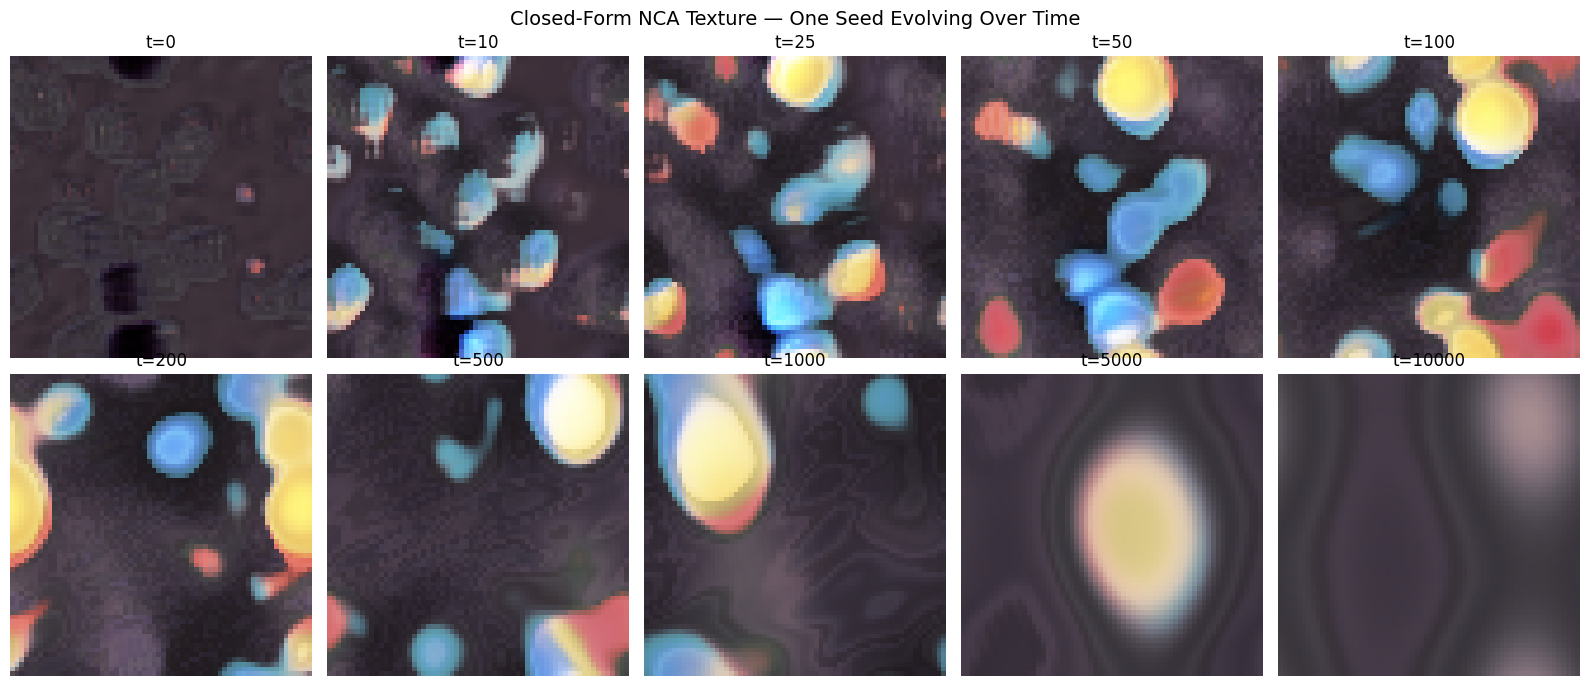

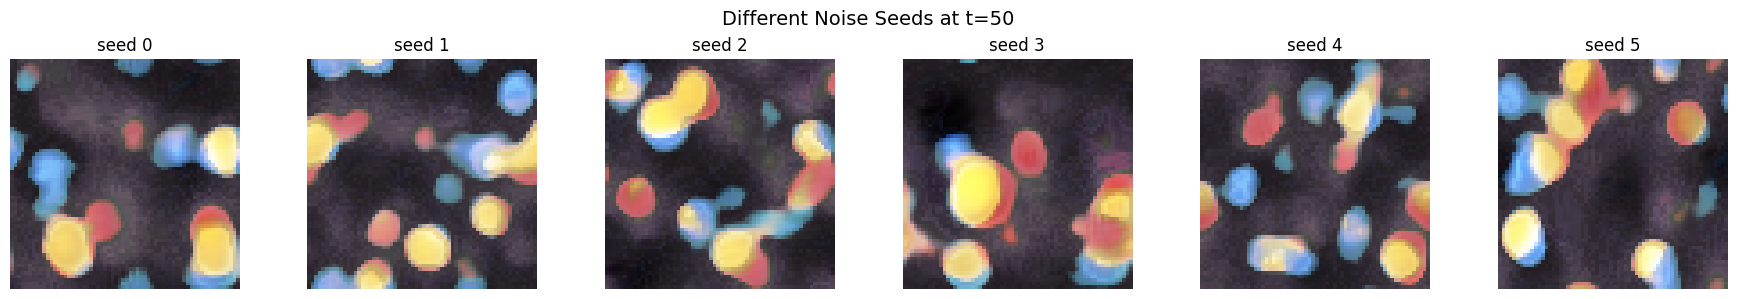

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
eval_times = [0, 10, 25, 50, 100, 200, 500, 1000, 5000, 10000]

# Same seed for all times so we see how one noise sample evolves
torch.manual_seed(0)
noise_seed = model._sample_noise()

with torch.no_grad():
    for i, t in enumerate(eval_times):
        row, col = divmod(i, 5)
        # Pass pixel-space noise_seed to forward
        pred = model(float(t), x0=noise_seed)

        # Output is batched [B, C, H, W], so we take [0]
        axes[row, col].imshow(pred[0].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[row, col].set_title(f't={t}')
        axes[row, col].axis('off')

plt.suptitle('Closed-Form NCA Texture — One Seed Evolving Over Time', fontsize=14)
plt.tight_layout()
plt.show()

# Different seeds at same time
fig2, axes2 = plt.subplots(1, 6, figsize=(18, 3))
with torch.no_grad():
    for i in range(6):
        pred = model(50.0)  # Generates fresh noise each call automatically
        axes2[i].imshow(pred[0].cpu().permute(1, 2, 0).clamp(0, 1))
        axes2[i].set_title(f'seed {i}')
        axes2[i].axis('off')
plt.suptitle('Different Noise Seeds at t=50', fontsize=14)
plt.tight_layout()
plt.show()

## Recurrent vs Closed-Form Comparison

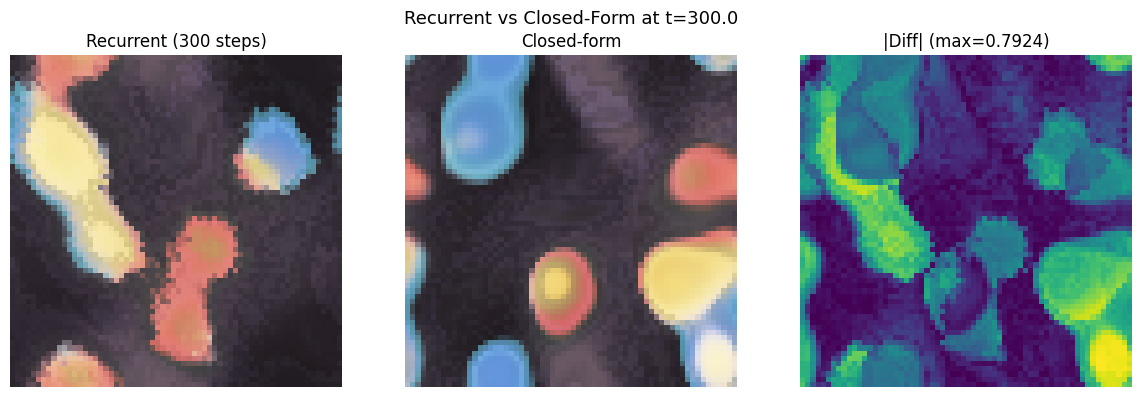

In [19]:
with torch.no_grad():
    T_compare = 300.0
    dt = 1.0  # Increased dt slightly for faster recurrent simulation
    n_steps = int(T_compare / dt)

    # 1. Base noise (pixel space)
    noise_0 = model._sample_noise()

    # 2. Recurrent Simulation
    state = model.get_initial_latent(x0=noise_0)
    for _ in range(n_steps):
        state = model.step_latent(state, dt=dt)
    rec_rgb = model.project(state)[0]  # Project latent to [3, H, W]

    # 3. Closed-form O(1) jump
    cf_rgb = model(T_compare, x0=noise_0)[0]  # Directly returns [3, H, W]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(rec_rgb.cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title(f'Recurrent ({n_steps} steps)')
    axes[0].axis('off')

    axes[1].imshow(cf_rgb.cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1].set_title('Closed-form')
    axes[1].axis('off')

    diff = (rec_rgb - cf_rgb).abs().mean(0)
    axes[2].imshow(diff.cpu(), cmap='viridis')
    axes[2].set_title(f'|Diff| (max={diff.max():.4f})')
    axes[2].axis('off')

    plt.suptitle(f'Recurrent vs Closed-Form at t={T_compare}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [22]:
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
import moviepy.editor as mvp

VIDEO_SIZE = 256
VIDEO_FPS = 30
VIDEO_SECONDS = 20
VIDEO_DT = 1.

n_frames = VIDEO_FPS * VIDEO_SECONDS

out_path = 'texture_nca.mp4'

with torch.no_grad():
    # Because of resolution-independence, we just initialize 256x256 noise.
    # The _generator_freq will perfectly mathematically pad the FFT!
    noise_v = model._sample_noise(batch_size=1, H=VIDEO_SIZE, W=VIDEO_SIZE)

    with FFMPEG_VideoWriter(out_path, (VIDEO_SIZE, VIDEO_SIZE), VIDEO_FPS) as writer:
        for i in range(n_frames):
            t = i * VIDEO_DT

            # The Separable model is so fast we don't need a fast_forward API.
            rgb = model(t, x0=noise_v)[0]

            frame = rgb.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
            writer.write_frame((frame * 255).astype(np.uint8))

print(f'Rendered {n_frames} frames → {out_path}')
mvp.ipython_display(out_path, maxduration=60)

Rendered 600 frames → texture_nca.mp4


In [21]:
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
import moviepy.editor as mvp

VIDEO_SIZE = 256
VIDEO_FPS = 30
VIDEO_SECONDS = 20
VIDEO_DT = 1.

n_frames = VIDEO_FPS * VIDEO_SECONDS

out_path = 'texture_nca.mp4'

with torch.no_grad():
    # Because of resolution-independence, we just initialize 256x256 noise.
    # The _generator_freq will perfectly mathematically pad the FFT!
    state = model._sample_noise(batch_size=1, H=VIDEO_SIZE, W=VIDEO_SIZE)

    with FFMPEG_VideoWriter(out_path, (VIDEO_SIZE, VIDEO_SIZE), VIDEO_FPS) as writer:
        for i in range(n_frames):
            t = i * VIDEO_DT

            # The Separable model is so fast we don't need a fast_forward API.
            rgb = model(t, x0=noise_v)[0]

            frame = rgb.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
            writer.write_frame((frame * 255).astype(np.uint8))

print(f'Rendered {n_frames} frames → {out_path}')
mvp.ipython_display(out_path, maxduration=60)

Rendered 600 frames → texture_nca.mp4
